## ABC (Artificial Bee Colony)

**Descripción:** El Artificial Bee Colony (ABC) es un algoritmo de optimización bioinspirado en el comportamiento de las colonias de abejas al buscar y explotar fuentes de alimento. Se basa en la cooperación entre tres tipos de abejas artificiales: obreras, observadoras y exploradoras, que trabajan juntas para encontrar soluciones óptimas a problemas complejos.

ABC es especialmente útil en problemas de optimización continua y discreta, donde las abejas exploran el espacio de búsqueda, evalúan la calidad de las soluciones y ajustan su estrategia en función de la información recolectada. Su simplicidad, flexibilidad y capacidad para evitar óptimos locales lo hacen adecuado para diversas aplicaciones en inteligencia artificial y optimización.

**Este algoritmo puede ser implementado tanto para un objetivo como para multiobjetivo** 

Fuentes del código:
-   https://www.datacamp.com/tutorial/swarm-intelligence?
-   https://github.com/BrianMburu/Artificial-Bee-Colony-in-python?

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def abc_algorithm(funcion_objetivo, limites, num_fuentes, iteraciones, limite_abandono):
    """
    Implementación del algoritmo de Colonia de Abejas Artificial (ABC) para minimizar una función objetivo.
    """
    num_variables = len(limites)
    fuentes = []

    # Inicialización de las fuentes de alimento
    for _ in range(num_fuentes):
        fuente = [random.uniform(limites[i][0], limites[i][1]) for i in range(num_variables)]
        fuentes.append({'posicion': fuente, 'valor': funcion_objetivo(fuente), 'contador': 0})

    # Listas para almacenar los mejores resultados cada 10 iteraciones
    best_solutions = []
    best_values = []

    # Bucle principal del algoritmo
    for iteracion in range(iteraciones):
        # Fase de abejas empleadas
        for i in range(num_fuentes):
            nueva_fuente = generar_vecina(fuentes[i]['posicion'], limites)
            nuevo_valor = funcion_objetivo(nueva_fuente)
            if nuevo_valor < fuentes[i]['valor']:
                fuentes[i] = {'posicion': nueva_fuente, 'valor': nuevo_valor, 'contador': 0}
            else:
                fuentes[i]['contador'] += 1

        # Cálculo de probabilidades para las abejas observadoras
        valores = [fuente['valor'] for fuente in fuentes]
        max_valor = max(valores)
        if max_valor == 0:
            probabilidades = [1 / num_fuentes] * num_fuentes
        else:
            probabilidades = [(max_valor - valor) / max_valor for valor in valores]
            suma_probabilidades = sum(probabilidades)
            probabilidades = [p / suma_probabilidades for p in probabilidades]

        # Fase de abejas observadoras
        for _ in range(num_fuentes):
            i = seleccionar_fuente(probabilidades)
            nueva_fuente = generar_vecina(fuentes[i]['posicion'], limites)
            nuevo_valor = funcion_objetivo(nueva_fuente)
            if nuevo_valor < fuentes[i]['valor']:
                fuentes[i] = {'posicion': nueva_fuente, 'valor': nuevo_valor, 'contador': 0}
            else:
                fuentes[i]['contador'] += 1

        # Fase de abejas exploradoras
        for i in range(num_fuentes):
            if fuentes[i]['contador'] >= limite_abandono:
                nueva_fuente = [random.uniform(limites[j][0], limites[j][1]) for j in range(num_variables)]
                fuentes[i] = {'posicion': nueva_fuente, 'valor': funcion_objetivo(nueva_fuente), 'contador': 0}

        # Guardamos el mejor resultado cada 10 iteraciones
        if (iteracion + 1) % 10 == 0:
            mejor_fuente = min(fuentes, key=lambda x: x['valor'])
            best_solutions.append(mejor_fuente['posicion'])
            best_values.append(mejor_fuente['valor'])

            # Imprimir el mejor valor y la mejor solución cada 10 iteraciones
            print(f"Iteración {iteracion + 1}: Mejor valor: {mejor_fuente['valor']}, Mejor solución: {mejor_fuente['posicion']}")

    # Graficar los resultados
    plt.figure(figsize=(8, 6))
    plt.plot(range(10, iteraciones + 1, 10), best_values, marker='o', color='g')
    plt.title("Mejor valor de la función objetivo ABC (cada 10 iteraciones)")
    plt.xlabel("Iteración")
    plt.ylabel("Mejor valor de la función objetivo")
    plt.grid(True)
    plt.show()

    # Devolver la mejor solución encontrada
    mejor_fuente = min(fuentes, key=lambda x: x['valor'])
    return mejor_fuente['posicion'], mejor_fuente['valor']

def generar_vecina(fuente, limites):
    """
    Genera una nueva solución vecina modificando una variable aleatoria de la solución actual.
    """
    vecina = fuente[:]
    i = random.randint(0, len(fuente) - 1)
    phi = random.uniform(-1, 1)
    vecina[i] = fuente[i] + phi * (fuente[i] - random.choice(fuente))
    vecina[i] = max(min(vecina[i], limites[i][1]), limites[i][0])
    return vecina

def seleccionar_fuente(probabilidades):
    """
    Selecciona una fuente de alimento basada en las probabilidades dadas.
    """
    r = random.uniform(0, 1)
    acumulado = 0
    for i, p in enumerate(probabilidades):
        acumulado += p
        if r <= acumulado:
            return i
    return len(probabilidades) - 1

## Parámetros del Algoritmo de Colonia de Abejas Artificial (ABC)

### `num_fuentes` (Número de fuentes de alimento)
- **Descripción**: Número de soluciones candidatas que el algoritmo mantiene en cada iteración. Cada una representa una "fuente de alimento".
- **Aumentar**: Mejora la exploración del espacio de búsqueda y la diversidad de soluciones, pero incrementa el tiempo de ejecución.
- **Disminuir**: Reduce el coste computacional, aunque puede llevar a una menor exploración y posible convergencia prematura.


### `iteraciones` (Número de iteraciones)
- **Descripción**: Número total de ciclos de mejora del algoritmo.
- **Aumentar**: Permite más refinamiento de soluciones, lo que puede mejorar la calidad final.
- **Disminuir**: Acelera el tiempo de ejecución, aunque puede detener el proceso antes de encontrar buenas soluciones.


### `limite_abandono` (Límite de abandono)
- **Descripción**: Número de ciclos sin mejora que puede tener una solución antes de ser descartada por una nueva aleatoria.
- **Aumentar**: Mantiene soluciones más tiempo, favoreciendo la explotación (refinamiento) de las mismas.
- **Disminuir**: Promueve una exploración más agresiva al reemplazar antes las soluciones poco prometedoras.


### `funcion_objetivo` (Función objetivo)
- **Descripción**: Es la función que se desea minimizar. Debe aceptar una lista de valores como entrada.
- **Importancia**: Define el problema de optimización. El comportamiento del algoritmo depende completamente de esta función.


### `limites` (Límites de las variables)
- **Descripción**: Lista de tuplas que establecen el rango permitido para cada variable del problema.
- **Ajuste**: Asegura que las soluciones generadas estén dentro de un espacio de búsqueda válido y controlado.

### `generar_vecina` (Generación de vecinas)
- **Descripción**: Mecanismo por el cual una solución se modifica para explorar el espacio cercano (búsqueda local).
- **Parámetro implícito (`phi`)**: Factor aleatorio entre -1 y 1 que controla la magnitud del cambio.  
- **Aumentar el rango de `phi`** (o cambiar su comportamiento): Puede aumentar la diversidad de vecinas, pero también generar soluciones menos estables.
- **Disminuir el rango**: Mejora la explotación local, pero puede dificultar escapar de óptimos locales.

### `probabilidades` (Probabilidad de selección por las abejas observadoras)
- **Descripción**: Determina qué soluciones tienen más probabilidad de ser elegidas por las abejas observadoras.
- **Aumentar la influencia de buenos valores (más sesgo)**: Acelera la convergencia hacia buenas soluciones.
- **Reducir el sesgo**: Aumenta la exploración y reduce el riesgo de quedar atrapado en óptimos locales.

El algoritmo ABC necesita un equilibrio entre **exploración** (probar muchas regiones del espacio de búsqueda) y **explotación** (refinar buenas soluciones).

- **Exploración**: Aumentar `num_fuentes`, reducir `limite_abandono`, mantener alta diversidad.
- **Explotación**: Aumentar `iteraciones`, usar un `limite_abandono` alto, favorecer mejores soluciones con las `probabilidades`.


Iteración 10: Mejor valor: 0.1351273872226936, Mejor solución: [0.011231778514615876, -0.3648760069001744, -0.04320571678234393]
Iteración 20: Mejor valor: 0.0007633498076143995, Mejor solución: [-0.003998507426490612, 0.005073502455335832, -0.02686301023359817]


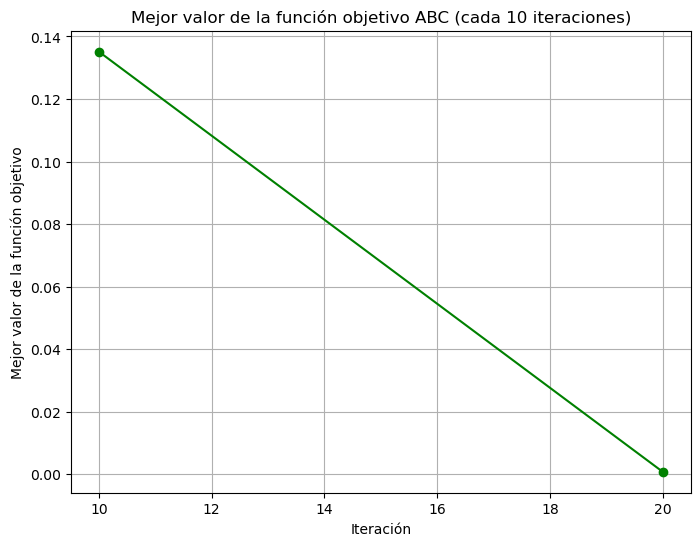

Mejor solución encontrada: [-0.003998507426490612, 0.005073502455335832, -0.02686301023359817]
Valor de la función objetivo: 0.0007633498076143995


In [2]:
def funcion_esfera(x):
    return sum(xi**2 for xi in x)

# Definir los límites para cada variable
limites = [(-5.12, 5.12)] * 3  # Para una función de 3 variables

# Ejecutar el algoritmo ABC
mejor_solucion, mejor_valor = abc_algorithm(
    funcion_objetivo=funcion_esfera,
    limites=limites,
    num_fuentes=20,
    iteraciones=20,
    limite_abandono=20
)

print("Mejor solución encontrada:", mejor_solucion)
print("Valor de la función objetivo:", mejor_valor)

Iteración 10: Mejor valor: 0.0018337433871866435, Mejor solución: [-0.016425606798848275, -0.009682842780133344, 0.03834299654658582]
Iteración 20: Mejor valor: 8.865653462939547e-05, Mejor solución: [0.0013925984338969098, -0.0026539521884542975, -0.008926014900990362]
Iteración 30: Mejor valor: 1.0342284190222558e-06, Mejor solución: [-0.00022608619986325, -0.00025825426036509, -0.000957297334299501]
Iteración 40: Mejor valor: 8.289225163742393e-08, Mejor solución: [-0.00019294260097287415, -0.00017187633446236197, -0.00012698003787614995]
Iteración 50: Mejor valor: 6.488509240798416e-10, Mejor solución: [2.3567500974191777e-05, 3.186311600012509e-06, 9.125307682425665e-06]
Iteración 60: Mejor valor: 3.6769183707702386e-11, Mejor solución: [6.0313184824598145e-06, -4.392606580012758e-07, 4.4657714358587245e-07]
Iteración 70: Mejor valor: 1.1764094470151238e-11, Mejor solución: [3.387378553740006e-06, 3.0054926158649154e-07, 4.4657714358587245e-07]
Iteración 80: Mejor valor: 2.6475567

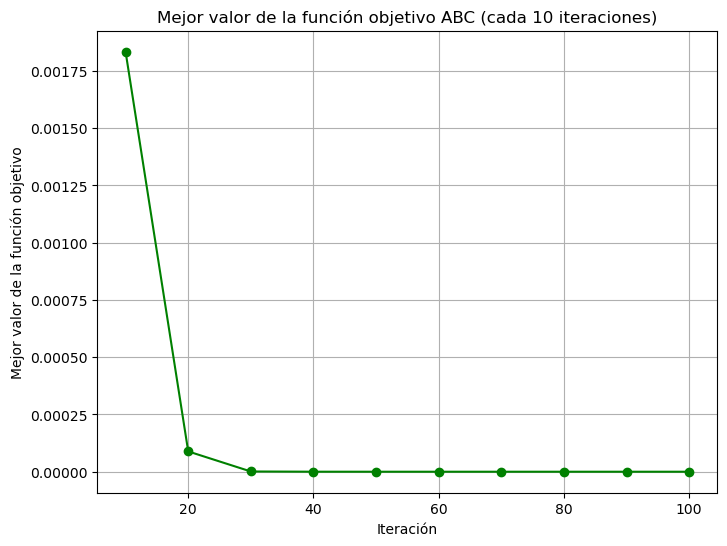

Exploración
Mejor solución encontrada: [-4.3535431766743476e-08, -1.1441367754869958e-08, -8.610458888591377e-09]
Valor de la función objetivo: 2.100378717491077e-15


In [3]:
def funcion_esfera(x):
    return sum(xi**2 for xi in x)

limites = [(-5.12, 5.12)] * 3  # 3 variables

# Parámetros enfocados en exploración
mejor_solucion, mejor_valor = abc_algorithm(
    funcion_objetivo=funcion_esfera,
    limites=limites,
    num_fuentes=50,         # Aumentamos la diversidad
    iteraciones=100,       # Iteraciones moderadas
    limite_abandono=20      # Se reemplazan soluciones pronto
)

print("Exploración")
print("Mejor solución encontrada:", mejor_solucion)
print("Valor de la función objetivo:", mejor_valor)


Iteración 10: Mejor valor: 0.010638418888406526, Mejor solución: [-0.018461430073553838, -0.10129553640169707, -0.006067025064912041]
Iteración 20: Mejor valor: 0.0028660503931896664, Mejor solución: [-0.004583376992812818, -0.05331853415672318, 0.0014754537979090971]
Iteración 30: Mejor valor: 0.0028466612770409344, Mejor solución: [-0.0015775728347026934, -0.05331853415672318, -0.0011430032241802899]
Iteración 40: Mejor valor: 2.7650295892867823e-05, Mejor solución: [-0.0012617882684930254, -0.004975111042768258, -0.0011430032241802899]
Iteración 50: Mejor valor: 3.1286867480973707e-06, Mejor solución: [-0.0011413097816383889, -0.0011248998023885457, -0.0007487984809146681]


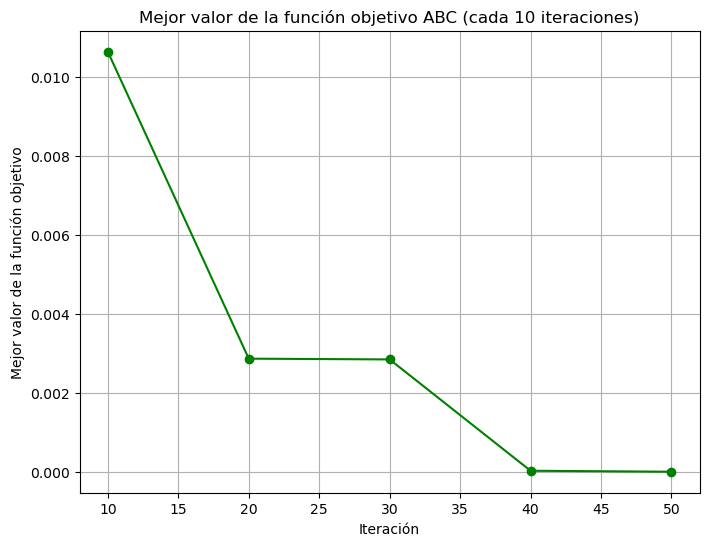

Explotación
Mejor solución encontrada: [-0.0011413097816383889, -0.0011248998023885457, -0.0007487984809146681]
Valor de la función objetivo: 3.1286867480973707e-06


In [4]:
def funcion_esfera(x):
    return sum(xi**2 for xi in x)

limites = [(-5.12, 5.12)] * 3  # 3 variables

# Parámetros enfocados en explotación
mejor_solucion, mejor_valor = abc_algorithm(
    funcion_objetivo=funcion_esfera,
    limites=limites,
    num_fuentes=10,          # Menos soluciones, pero más refinadas
    iteraciones=50,        # Muchas iteraciones para pulir soluciones
    limite_abandono=200      # Las fuentes se mantienen mucho tiempo
)

print("Explotación")
print("Mejor solución encontrada:", mejor_solucion)
print("Valor de la función objetivo:", mejor_valor)


### **Resolución de TSP con ABC**  
**Principio:** Se basa en el comportamiento de las abejas en la búsqueda de alimento, dividiendo la población en abejas obreras, observadoras y exploradoras.  

**Cómo resuelve el TSP:**  
1. Se generan múltiples soluciones aleatorias (caminos diferentes entre ciudades).  
2. Cada abeja obrera mejora su ruta modificando algunas conexiones entre ciudades.  
3. Las abejas observadoras eligen soluciones de alta calidad para seguir explorando.  
4. Si una solución no mejora después de varias iteraciones, una abeja exploradora genera una nueva solución aleatoria.  
5. Se repiten iteraciones hasta alcanzar una ruta óptima o cumplir un criterio de parada.  

✅ **Ventajas:**  
- Buena capacidad de exploración y diversidad de soluciones.  
- Se evita el estancamiento mediante el uso de abejas exploradoras.  

❌ **Desventajas:**  
- Puede ser más lento en la convergencia en comparación con ACO.  
- La calidad de la solución depende de la estrategia de actualización de soluciones.  

---

Hay que tener en cuenta que este problema es de un solo objetivo (single-objective), ya que solo se busca minimizar la distancia total recorrida. Por lo tanto, el ABC implementado para resolver este problema será una optimización de un solo objetivo.

Mejor ruta encontrada: [0 9 4 7 5 1 6 3 8 2], Distancia total: 3.669086606741704


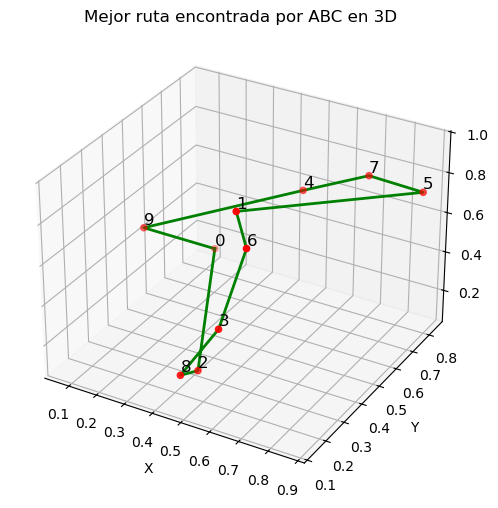

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def distance(point1, point2):
    return np.linalg.norm(point1 - point2)

def total_distance(path, points):
    return sum(distance(points[path[i]], points[path[i + 1]]) for i in range(len(path) - 1)) + distance(points[path[-1]], points[path[0]])

def initialize_population(size, n_points):
    return [np.random.permutation(n_points) for _ in range(size)]

def abc_tsp(n_bees, points, max_iter):
    n_points = len(points)
    food_sources = initialize_population(n_bees, n_points)
    fitness = np.array([total_distance(fs, points) for fs in food_sources])
    trial_counters = np.zeros(n_bees)
    best_solution = food_sources[np.argmin(fitness)]
    best_fitness = np.min(fitness)

    for iteration in range(max_iter):
        for i in range(n_bees):
            swap_idx = np.random.choice(n_points, 2, replace=False)
            new_solution = food_sources[i].copy()
            new_solution[swap_idx] = new_solution[swap_idx[::-1]]
            new_fitness = total_distance(new_solution, points)
            if new_fitness < fitness[i]:
                food_sources[i] = new_solution
                fitness[i] = new_fitness
                trial_counters[i] = 0
            else:
                trial_counters[i] += 1

        probability = (fitness.max() - fitness) / (fitness.max() - fitness.min() + 1e-8)
        for i in range(n_bees):
            if np.random.rand() < probability[i]:
                swap_idx = np.random.choice(n_points, 2, replace=False)
                new_solution = food_sources[i].copy()
                new_solution[swap_idx] = new_solution[swap_idx[::-1]]
                new_fitness = total_distance(new_solution, points)
                if new_fitness < fitness[i]:
                    food_sources[i] = new_solution
                    fitness[i] = new_fitness
                    trial_counters[i] = 0
                else:
                    trial_counters[i] += 1

        for i in range(n_bees):
            if trial_counters[i] > max_iter // 5:
                food_sources[i] = np.random.permutation(n_points)
                fitness[i] = total_distance(food_sources[i], points)
                trial_counters[i] = 0

        current_best = np.min(fitness)
        if current_best < best_fitness:
            best_fitness = current_best
            best_solution = food_sources[np.argmin(fitness)]

    return best_solution, best_fitness

# Parámetros
n_points = 10
points = np.random.rand(n_points, 3)
n_bees = 20
max_iter = 100

best_path, best_fit = abc_tsp(n_bees, points, max_iter)
print(f"Mejor ruta encontrada: {best_path}, Distancia total: {best_fit}")

# Visualización en 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='red', marker='o')
for i in range(n_points):
    ax.text(points[i, 0], points[i, 1], points[i, 2], str(i), fontsize=12, verticalalignment='bottom')
path = np.append(best_path, best_path[0])
ax.plot(points[path, 0], points[path, 1], points[path, 2], 'g-', linewidth=2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("Mejor ruta encontrada por ABC en 3D")
plt.show()